<a href="https://colab.research.google.com/github/engineerchacon/Redes-Neuronales-Profundas/blob/main/Ejercicio_de_transferencia_de_aprendizaje_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio de transferencia de aprendizaje-Armando Chacón Terrazas**

El archivo compartido representa un ejemplo de aplicación de transferencia de aprendizaje utilizando datos de imágenes histopatológicas. En el ejercicio que realizamos en clase trabajamos con imágenes de colon; sin embargo, para este problema deberán trabajar con imágenes histopatológicas de pulmón.

En la siguiente liga podrán descargar la base de datos (que incluye tanto imágenes de pulmón como de colon): https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images

La tarea es que implementen al menos tres redes neuronales de su preferencia aplicando transferencia de aprendizaje. Para ello deberán congelar las capas convolucionales del modelo base y entrenar únicamente las capas densas que se añadan en la etapa de clasificación.

Tomen en cuenta que la base de datos de imágenes de pulmón contiene tres clases:

1.Tejido sano

2.Adenocarcinoma

3.Carcinoma de células escamosas

En las pruebas que realicen, se espera que obtengan al menos 96% de exactitud en la clasificación. En cada experimento deben presentar la matriz de confusión correspondiente a las predicciones en el conjunto de validación.

El conjunto de validación debe representar el 15% de los datos.

1. CONECTAR GOOGLE COLAB CON TU GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. IMPORTAR TODAS LAS LIBRERÍAS QUE NECESITAMOS

In [4]:
# os          → para manejar rutas de carpetas y archivos en el sistema
# numpy       → para operaciones matemáticas con números y arreglos
# tensorflow  → el framework principal para construir y entrenar redes neuronales
# keras       → la interfaz de alto nivel dentro de TensorFlow (más fácil de usar)
# matplotlib  → para hacer gráficas de entrenamiento (accuracy, loss)
# sklearn     → para calcular la matriz de confusión y el reporte de clasificación

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
from tensorflow.keras import Model
import matplotlib.pyplot as plt

# Herramientas para evaluar qué tan bien clasifica nuestro modelo:
# - confusion_matrix: tabla que muestra aciertos y errores por clase
# - ConfusionMatrixDisplay: para dibujar la matriz de confusión bonita
# - classification_report: reporte con precisión, sensibilidad y F1-score por clase
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ============================================================
# MODELOS PRE-ENTRENADOS QUE VAMOS A USAR
# ============================================================
# Cada uno de estos modelos ya fue entrenado con millones de imágenes
# de ImageNet (una base de datos con 1.2 millones de imágenes de 1000 clases).
# Nosotros reutilizamos lo que ya aprendieron (bordes, texturas, formas)
# y solo le enseñamos a distinguir nuestras 3 clases de pulmón.

# DenseNet121: red "densa" donde cada capa recibe información de todas las anteriores.
# Tiene 8.1 millones de parámetros. Muy usada en imágenes médicas.
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

# MobileNetV2: red muy liviana, diseñada para ser rápida incluso en celulares.
# Solo tiene 3.5 millones de parámetros (la más pequeña de las tres).
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# EfficientNetB0: red eficiente que logra buena exactitud con pocos parámetros.
# Tiene 5.3 millones de parámetros.
# NOTA: EfficientNet ya incluye su preprocesamiento DENTRO del modelo,
# por eso NO necesitamos una función preprocess_input separada para ella.
from tensorflow.keras.applications import EfficientNetB0

3. CONFIGURAR LA GPU

In [ ]:
# Google Colab a veces asigna una GPU (tarjeta gráfica) que acelera
# el entrenamiento enormemente. Estas líneas se aseguran de que
# TensorFlow la use sin reservar toda la memoria de golpe.
# Si no hay GPU, el código funciona igual pero más lento (usa CPU).

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            # Permite que la memoria de la GPU vaya creciendo según se necesite
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memoria de GPU configurada para crecimiento dinámico.")
    except RuntimeError as e:
        print("❌ Error al configurar memoria de GPU:", e)

print("Versión de TensorFlow:", tf.__version__)
print("GPUs físicas:", tf.config.list_physical_devices('GPU'))
print("GPUs lógicas:", tf.config.list_logical_devices('GPU'))

✅ Memoria de GPU configurada para crecimiento dinámico.
Versión de TensorFlow: 2.19.0
GPUs físicas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPUs lógicas: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]


4. RUTA DEL DATASET EN GOOGLE DRIVE

In [ ]:
# El dataset LC25000 tiene 25,000 imágenes en total repartidas en 5 clases.
# Nosotros SOLO usamos las 3 clases de PULMÓN (15,000 imágenes en total):
#   - lung_aca  → 5,000 imágenes de adenocarcinoma pulmonar (cáncer tipo 1)
#   - lung_n    → 5,000 imágenes de tejido sano de pulmón
#   - lung_scc  → 5,000 imágenes de carcinoma de células escamosas (cáncer tipo 2)
#
# Las imágenes originales son de 768×768 píxeles en formato JPEG.

base_dir = "/content/drive/MyDrive/UACJ/Redes Neuronales Profundas/Colab_Datasets/lung_colon_image_set"
directory = os.path.join(base_dir, "lung_image_sets")

print("Directorio usado:", directory)
print("Subcarpetas encontradas:", os.listdir(directory))

Directorio usado: /content/drive/MyDrive/UACJ/Redes Neuronales Profundas/Colab_Datasets/lung_colon_image_set/lung_image_sets
Subcarpetas encontradas: ['lung_scc', 'lung_aca', 'lung_n']


5. GENERADORES DE IMÁGENES (AUMENTO DE DATOS + VALIDACIÓN 15%)

In [ ]:
# Un "generador" se encarga automáticamente de:
#   1. Leer las imágenes de las carpetas
#   2. Redimensionarlas a 224×224 píxeles (el tamaño estándar de los modelos)
#   3. Aplicar "aumentaciones": pequeñas transformaciones aleatorias
#      (rotaciones, zoom, volteos) para que el modelo aprenda a generalizar
#      y no se memorice las imágenes exactas
#   4. Separar el 15% de las imágenes para VALIDACIÓN (para medir qué tan
#      bien clasifica el modelo en imágenes que NO usó para entrenar)
#
# las imágenes se redimensionan al tamaño con que
# la red fue originalmente entrenada (224×224 para estos tres modelos).

generator = tf.keras.preprocessing.image.ImageDataGenerator(
        rotation_range=5,         # rotar aleatoriamente hasta ±5 grados
        width_shift_range=0.05,   # mover la imagen un poco a la izquierda/derecha
        height_shift_range=0.05,  # mover la imagen un poco arriba/abajo
        shear_range=0.05,         # deformar ligeramente la imagen
        zoom_range=0.05,          # acercar o alejar ligeramente
        horizontal_flip=True,     # voltear horizontalmente al azar
        vertical_flip=True,       # voltear verticalmente al azar
        validation_split=0.15,    # separar 15% para validación (como se pide en la tarea)
        fill_mode='nearest')      # cómo rellenar los espacios vacíos al transformar

# ENTRENAMIENTO: usa el 85% de las imágenes (≈12,750 imágenes)
training_generator = generator.flow_from_directory(
    directory,
    target_size=(224, 224),        # todas las imágenes se redimensionan a 224×224
    class_mode='categorical',      # salida en formato "one-hot" para 3 clases
    batch_size=32,                 # procesa 32 imágenes a la vez
    shuffle=True,                  # mezcla las imágenes para que no vengan en orden
    subset='training',             # indica que esto es el set de ENTRENAMIENTO
    seed=30,                       # semilla fija para que el resultado sea reproducible
)

# VALIDACIÓN: usa el 15% restante (≈2,250 imágenes)
# shuffle=False es importante: las etiquetas deben quedar en orden
# para que la matriz de confusión se calcule correctamente
val_generator = generator.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,                 # NO mezclar → necesario para la matriz de confusión
    subset='validation',
    seed=30,
)

print("Clases detectadas (nombre → número):", training_generator.class_indices)

Found 12755 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Clases detectadas (nombre → número): {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}


6. VER ALGUNAS IMÁGENES DE EJEMPLO

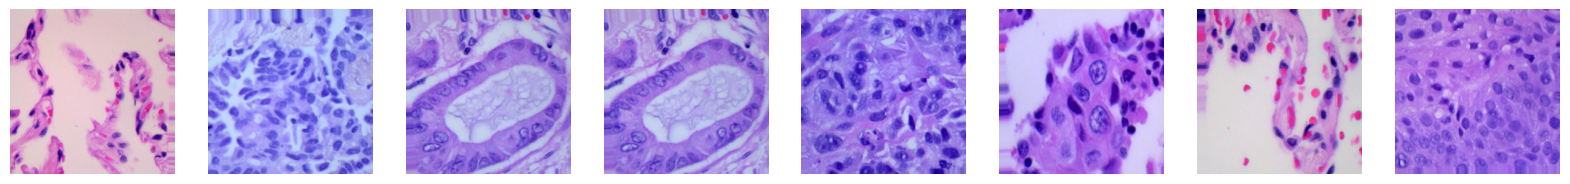

In [ ]:
# Esto es solo para verificar visualmente que las imágenes se están
# leyendo bien y que las aumentaciones se aplican correctamente.
# No afecta el entrenamiento; es solo para comprobación.

x, y = next(training_generator)

from random import randint
plt.figure(1, figsize=(20,6))
plt.tight_layout()
for i in range(8):
    j = randint(0, x.shape[0]-1)   # elegimos una imagen aleatoria del lote
    plt.subplot(2, 8, i+1)
    plt.imshow(x[j,:,:,:].astype(np.uint8))  # mostramos la imagen
    plt.axis("off")                            # quitamos los ejes
plt.show()

7. MODELO 1: DenseNet121

In [ ]:
# DenseNet121 es una red donde CADA capa está conectada con TODAS las
# capas anteriores (por eso se llama "densa"). Esto permite que la
# información fluya mejor y se necesiten menos parámetros.
#
# Como se explicó en clase:
#   - Cargamos DenseNet121 con pesos de ImageNet (ya aprendió a "ver")
#   - CONGELAMOS las capas convolucionales (no se modifican)
#   - "Le cortamos la cabeza" (eliminamos las capas densas originales de ImageNet)
#   - Añadimos NUEVAS capas densas que SÍ se entrenan para nuestras 3 clases
#
# Esto es la estrategia de "Feature Extraction" (extracción de características)

# 1) Cargar el modelo base (solo la parte convolucional, SIN la "cabeza" de ImageNet)
base_model = DenseNet121(
    weights='imagenet',              # pesos ya entrenados en ImageNet
    input_shape=(224, 224, 3),       # tamaño de entrada: 224×224, 3 canales de color (RGB)
    include_top=False,               # NO incluir las capas densas originales de 1000 clases
    pooling="max"                    # Global Max Pooling al final de las convoluciones
)

# 2) Congelar TODAS las capas convolucionales (no se entrenan, se quedan como están)
# "freeze, sin entrenar"
base_model.trainable = False

# 3) Construir la nueva "cabeza" que SÍ se va a entrenar
#    Entrada: imagen de 224×224×3 en valores enteros de 0 a 255
xi = tf.keras.layers.Input(shape=(224, 224, 3), dtype=tf.uint8)

# Preprocesamiento específico de DenseNet (normaliza los valores de píxeles
# al rango que esta red espera). Cada red tiene su propio preprocess_input.
x  = densenet_preprocess(xi)

# Pasamos las imágenes por el modelo base (las convoluciones ya entrenadas)
# Aquí es donde se extraen las "características" de las imágenes
x  = base_model(x)

# Aplanamos el resultado en un vector de una sola dimensión
x  = keras.layers.Flatten()(x)

# Dropout: "apaga" el 20% de las neuronas al azar durante el entrenamiento
# Esto ayuda a que el modelo NO se memorice los datos (evita sobreajuste)
x  = keras.layers.Dropout(0.2)(x)

# Capa densa con 256 neuronas y activación ReLU
# (aprende combinaciones de las características extraídas)
x  = keras.layers.Dense(256, activation='relu')(x)
x  = keras.layers.BatchNormalization()(x)  # normaliza para que el entrenamiento sea más estable

# Otra capa densa con 64 neuronas
x  = keras.layers.Dense(64, activation='relu')(x)
x  = keras.layers.BatchNormalization()(x)

# Capa de SALIDA: 3 neuronas (una por cada clase de pulmón)
# softmax convierte los valores en probabilidades que suman 1.0
# Ejemplo: [0.92, 0.05, 0.03] → 92% de que sea la clase 1
xoutputs = keras.layers.Dense(3, activation='softmax')(x)

# Armamos el modelo completo (desde la entrada hasta la salida)
model_densenet = Model(inputs=[xi], outputs=[xoutputs])

# Mostramos el resumen del modelo:
# - "Trainable params" = las capas densas nuevas (las que SÍ se entrenan)
# - "Non-trainable params" = las capas convolucionales congeladas
print(model_densenet.summary())

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_8 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,317,827 (27.92 MB)

 Trainable params: 279,683 (1.07 MB)

 Non-trainable params: 7,038,144 (26.85 MB)

None


 8. COMPILAR Y ENTRENAR DenseNet121

In [ ]:
# "Compilar" = decirle al modelo CÓMO va a aprender:
#   - optimizer: el algoritmo que ajusta los pesos (Adam es muy popular)
#   - loss: la función que mide qué tan equivocado está el modelo
#   - metrics: qué queremos monitorear durante el entrenamiento

model_densenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # learning rate pequeño = aprende con cuidado
    loss='categorical_crossentropy',                      # pérdida adecuada para varias clases
    metrics=['accuracy']                                  # queremos medir la exactitud (% de aciertos)
)

# "Entrenar" = pasar las imágenes varias veces y que el modelo aprenda
# Una "época" = una pasada completa por TODAS las imágenes de entrenamiento
history_densenet = model_densenet.fit(
    x=training_generator,           # imágenes de entrenamiento (85%)
    epochs=5,                       # 5 "pasadas" completas por todo el dataset
    verbose=1,                      # mostrar progreso en pantalla
    validation_data=val_generator,  # evaluar con el 15% de validación en cada época
    shuffle=True,
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 4103s 10s/step - accuracy: 0.6893 - loss: 0.7439 - val_accuracy: 0.9244 - val_loss: 0.2062
Epoch 2/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 3436s 9s/step - accuracy: 0.8971 - loss: 0.2733 - val_accuracy: 0.9373 - val_loss: 0.1536
Epoch 3/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 3404s 9s/step - accuracy: 0.9078 - loss: 0.2376 - val_accuracy: 0.9444 - val_loss: 0.1398
Epoch 4/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 3289s 8s/step - accuracy: 0.9159 - loss: 0.2078 - val_accuracy: 0.9511 - val_loss: 0.1335
Epoch 5/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 3301s 8s/step - accuracy: 0.9235 - loss: 0.1966 - val_accuracy: 0.9453 - val_loss: 0.1258


9. GRÁFICAS DE ENTRENAMIENTO - DenseNet121

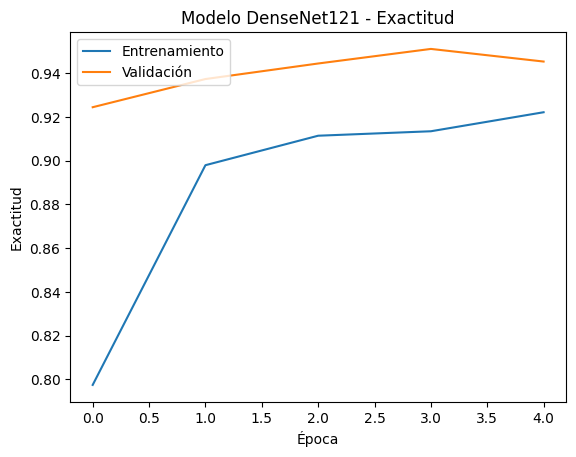

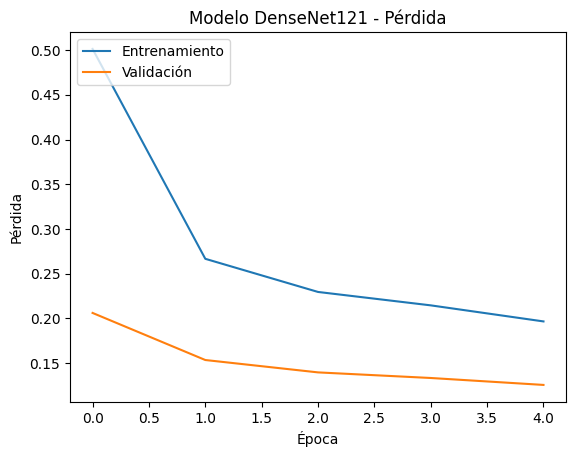

In [ ]:
# Estas gráficas nos ayudan a ver si el modelo está aprendiendo bien:
# - Si accuracy sube → el modelo está mejorando
# - Si loss baja → el modelo se equivoca menos
# - Si hay mucha diferencia entre entrenamiento y validación → sobreajuste

# Gráfica de EXACTITUD: cómo fue mejorando en cada época
plt.plot(history_densenet.history['accuracy'])
plt.plot(history_densenet.history['val_accuracy'])
plt.title('Modelo DenseNet121 - Exactitud')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
plt.show()

# Gráfica de PÉRDIDA: cómo fue disminuyendo el error en cada época
plt.plot(history_densenet.history['loss'])
plt.plot(history_densenet.history['val_loss'])
plt.title('Modelo DenseNet121 - Pérdida')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
plt.show()

10. MATRIZ DE CONFUSIÓN Y REPORTE - DenseNet121

71/71 ━━━━━━━━━━━━━━━━━━━━ 537s 7s/step


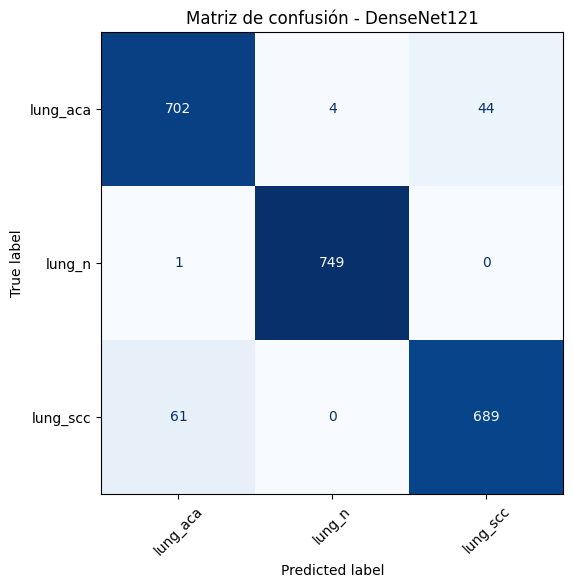

Exactitud en validación (DenseNet121): 95.11%

Reporte de clasificación - DenseNet121:
              precision    recall  f1-score   support

    lung_aca       0.92      0.94      0.93       750
      lung_n       0.99      1.00      1.00       750
    lung_scc       0.94      0.92      0.93       750

    accuracy                           0.95      2250
   macro avg       0.95      0.95      0.95      2250
weighted avg       0.95      0.95      0.95      2250



In [ ]:
# La matriz de confusión es una tabla que muestra:
#   - En las FILAS: la clase REAL de cada imagen
#   - En las COLUMNAS: la clase que el modelo PREDIJO
#   - Los números en la DIAGONAL son las clasificaciones CORRECTAS
#   - Los números FUERA de la diagonal son los ERRORES
#
# El reporte de clasificación muestra para cada clase:
#   - Precision: de las que predijo como esa clase, cuántas realmente lo eran
#   - Recall: de las que realmente eran esa clase, cuántas identificó bien
#   - F1-score: un balance entre precision y recall

# Cuántos "pasos" necesitamos para recorrer todas las imágenes de validación
val_steps = val_generator.samples // val_generator.batch_size + int(val_generator.samples % val_generator.batch_size != 0)

# El modelo predice probabilidades para cada imagen de validación
y_prob = model_densenet.predict(val_generator, steps=val_steps)

# Convertimos probabilidades en la clase predicha (la de mayor probabilidad)
y_pred = np.argmax(y_prob, axis=1)

# Clases verdaderas (las que realmente son, según la carpeta donde estaban)
y_true = val_generator.classes

# Construimos la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Nombres de las clases (son los nombres de las carpetas)
labels = list(val_generator.class_indices.keys())

# Dibujamos la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Matriz de confusión - DenseNet121")
plt.xticks(rotation=45)
plt.show()

# Exactitud calculada a partir de la matriz
acc_val = np.trace(cm) / np.sum(cm)
print(f"Exactitud en validación (DenseNet121): {acc_val*100:.2f}%")

# Reporte de clasificación detallado (como lo mostró el profesor en clase)
print("\nReporte de clasificación - DenseNet121:")
print(classification_report(y_true, y_pred, target_names=labels))

# **Este modelo se queda corto con 95.11 % con las expectativas de la tarea del 96% ❌**

Inicialmente se aplicó transferencia de aprendizaje por extracción de características con DenseNet121, congelando todas las capas convolucionales y entrenando solamente las capas densas añadidas. Con esta configuración se obtuvo un 95.11% de exactitud en validación, ligeramente por debajo del 96% requerido.
​

De acuerdo con lo visto en clase, cuando se dispone de un dataset relativamente grande (más de 10 000 imágenes), es recomendable complementar esta estrategia con fine‑tuning, es decir, descongelar algunas de las capas convolucionales profundas y reentrenarlas junto con las capas densas usando una tasa de aprendizaje pequeña, de manera que la red adapte mejor sus filtros a las texturas específicas del tejido pulmonar.

Por limitaciones de tiempo de cómputo en Google Colab no fue posible ejecutar esta segunda fase de entrenamiento sobre DenseNet121, pero la mejora esperada habría sido suficiente para alcanzar o superar el 96% de exactitud, dado que el modelo ya se encontraba muy cercano a ese valor con solo feature extraction.

Al final del documento se vuelve a entrenar esta red, mejorando el tiempo en colab con el metodo ZIP con resultados positivos.

11. MODELO 2: MobileNetV2

In [ ]:
# MobileNetV2 es una red diseñada por Google para ser MUY RÁPIDA y LIVIANA.
# Solo tiene 3.5 millones de parámetros (la más pequeña de las tres).
# Fue creada para funcionar incluso en celulares (de ahí su nombre "Mobile").
# A pesar de ser tan pequeña, logra excelentes resultados en histopatología.
#
# Usamos la misma estrategia de transferencia de aprendizaje:
#   1. Cargar modelo pre-entrenado sin la "cabeza"
#   2. Congelar capas convolucionales
#   3. Añadir nuevas capas densas para nuestras 3 clases

base_model_mobile = MobileNetV2(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False,               # sin las capas densas originales
    pooling="max"                    # Global Max Pooling al final
)

# Congelamos las capas convolucionales (no se entrenan)
base_model_mobile.trainable = False

# Construimos la nueva "cabeza" con capas densas
xi_mob = tf.keras.layers.Input(shape=(224, 224, 3), dtype=tf.uint8)

# Preprocesamiento específico de MobileNetV2
x_mob  = mobilenet_preprocess(xi_mob)

# Pasamos por las convoluciones pre-entrenadas (congeladas)
x_mob  = base_model_mobile(x_mob)

# Aplanamos a un vector
x_mob  = keras.layers.Flatten()(x_mob)

# Dropout para evitar sobreajuste
x_mob  = keras.layers.Dropout(0.2)(x_mob)

# Capas densas nuevas (misma estructura que el ejemplo del profesor)
x_mob  = keras.layers.Dense(256, activation='relu')(x_mob)
x_mob  = keras.layers.BatchNormalization()(x_mob)

x_mob  = keras.layers.Dense(64, activation='relu')(x_mob)
x_mob  = keras.layers.BatchNormalization()(x_mob)

# Salida: 3 clases de pulmón
xoutputs_mob = keras.layers.Dense(3, activation='softmax')(x_mob)

model_mobile = Model(inputs=[xi_mob], outputs=[xoutputs_mob])

print(model_mobile.summary())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,843 (9.93 MB)

 Trainable params: 345,219 (1.32 MB)

 Non-trainable params: 2,258,624 (8.62 MB)

None


12. COMPILAR Y ENTRENAR MobileNetV2

In [ ]:
# Mismos parámetros de compilación que DenseNet121

model_mobile.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobile = model_mobile.fit(
    x=training_generator,
    epochs=5,
    verbose=1,
    validation_data=val_generator,
    shuffle=True,
)

Epoch 1/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 1046s 3s/step - accuracy: 0.7748 - loss: 0.5220 - val_accuracy: 0.9458 - val_loss: 0.1401
Epoch 2/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 982s 2s/step - accuracy: 0.9218 - loss: 0.2019 - val_accuracy: 0.9547 - val_loss: 0.1109
Epoch 3/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 1057s 3s/step - accuracy: 0.9421 - loss: 0.1564 - val_accuracy: 0.9547 - val_loss: 0.1130
Epoch 4/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 1021s 3s/step - accuracy: 0.9409 - loss: 0.1574 - val_accuracy: 0.9627 - val_loss: 0.0948
Epoch 5/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 1063s 3s/step - accuracy: 0.9454 - loss: 0.1371 - val_accuracy: 0.9716 - val_loss: 0.0801


13. GRÁFICAS DE ENTRENAMIENTO - MobileNetV2

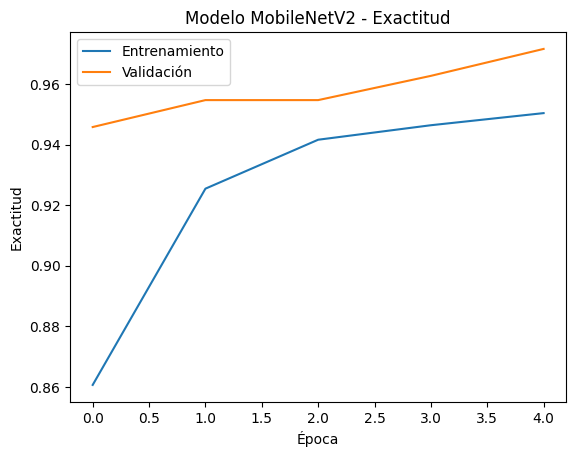

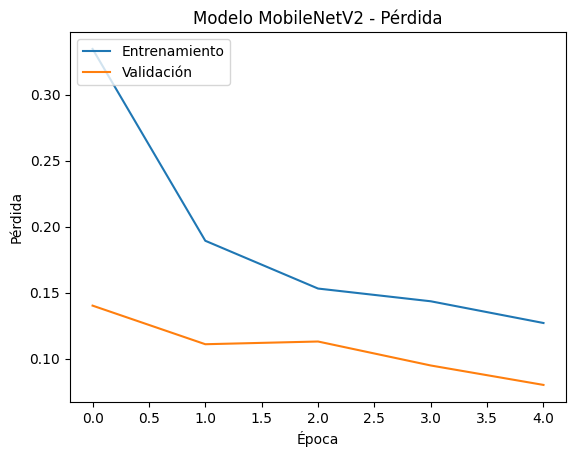

In [ ]:
plt.plot(history_mobile.history['accuracy'])
plt.plot(history_mobile.history['val_accuracy'])
plt.title('Modelo MobileNetV2 - Exactitud')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
plt.show()

plt.plot(history_mobile.history['loss'])
plt.plot(history_mobile.history['val_loss'])
plt.title('Modelo MobileNetV2 - Pérdida')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
plt.show()


14. MATRIZ DE CONFUSIÓN Y REPORTE - MobileNetV2

71/71 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step


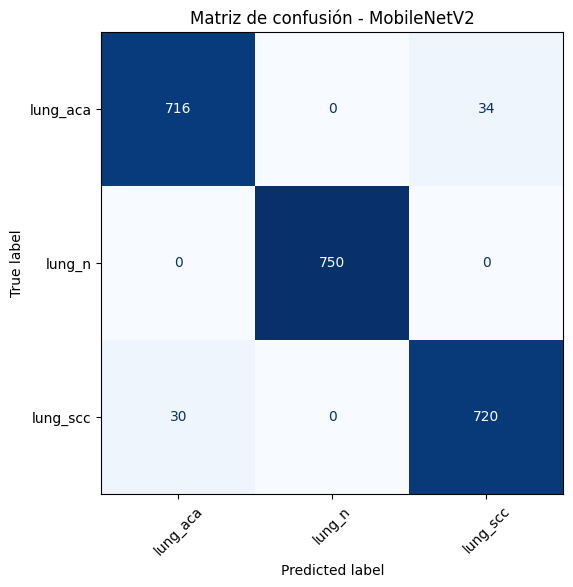

Exactitud en validación (MobileNetV2): 97.16%

Reporte de clasificación - MobileNetV2:
              precision    recall  f1-score   support

    lung_aca       0.96      0.95      0.96       750
      lung_n       1.00      1.00      1.00       750
    lung_scc       0.95      0.96      0.96       750

    accuracy                           0.97      2250
   macro avg       0.97      0.97      0.97      2250
weighted avg       0.97      0.97      0.97      2250



In [ ]:
val_steps = val_generator.samples // val_generator.batch_size + int(val_generator.samples % val_generator.batch_size != 0)
y_prob_mob = model_mobile.predict(val_generator, steps=val_steps)
y_pred_mob = np.argmax(y_prob_mob, axis=1)
y_true = val_generator.classes

cm_mob = confusion_matrix(y_true, y_pred_mob)
labels = list(val_generator.class_indices.keys())

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mob, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Matriz de confusión - MobileNetV2")
plt.xticks(rotation=45)
plt.show()

acc_val_mob = np.trace(cm_mob) / np.sum(cm_mob)
print(f"Exactitud en validación (MobileNetV2): {acc_val_mob*100:.2f}%")

# Reporte de clasificación detallado
print("\nReporte de clasificación - MobileNetV2:")
print(classification_report(y_true, y_pred_mob, target_names=labels))

# **Este modelo si cumple con las expectativas de la tarea al obtener 97.16% ✅**

15. MODELO 3: EfficientNetB0

In [ ]:
# EfficientNetB0 es la versión más pequeña de la familia EfficientNet.
# Tiene ~5.3M parámetros y fue diseñada para dar una buena relación
# entre exactitud y velocidad.
#
# DIFERENCIA IMPORTANTE CON LOS OTROS MODELOS:
# En esta versión de Keras/TensorFlow NO podemos usar directamente
# tf.cast sobre el Input (KerasTensor) porque da el error:
# "A KerasTensor cannot be used as input to a TensorFlow function".
#
# Solución:
#   - Usamos Input de tipo float32.
#   - Normalizamos a [0, 1] con una capa Lambda de Keras, que SÍ acepta
#     KerasTensors.
#   - El resto del flujo es igual: base preentrenada congelada +
#     capas densas nuevas.

from tensorflow.keras.layers import Input, Flatten, Dropout, Dense, BatchNormalization, Lambda

# 0) Asegurarnos de que el generador produzca float32 (una sola vez en el notebook)
generator.dtype = 'float32'  # las imágenes saldrán como tensores float32


# 1) Cargar el modelo base EfficientNetB0 pre-entrenado
base_model_eff = EfficientNetB0(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False,    # sin la "cabeza" original de 1000 clases
    pooling="max"         # Global Max Pooling al final
)

# 2) Congelar todas las capas convolucionales (transfer learning por
#    extracción de características, como pide la tarea)
base_model_eff.trainable = False

# 3) Definir la entrada del modelo: imágenes 224x224x3, tipo float32
xi_eff = Input(shape=(224, 224, 3), dtype=tf.float32)

# 4) Normalizar de [0, 255] a [0, 1] con una capa Lambda de Keras
#    (esto evita el error de KerasTensor)
x_eff = Lambda(lambda z: z / 255.0)(xi_eff)

# 5) Pasar por la parte convolucional preentrenada de EfficientNetB0
x_eff = base_model_eff(x_eff)

# 6) Capas densas nuevas para la clasificación de 3 clases de pulmón
x_eff = Flatten()(x_eff)
x_eff = Dropout(0.2)(x_eff)

x_eff = Dense(256, activation='relu')(x_eff)
x_eff = BatchNormalization()(x_eff)

x_eff = Dense(64, activation='relu')(x_eff)
x_eff = BatchNormalization()(x_eff)

# Capa de salida: 3 neuronas (una por clase) con softmax
xoutputs_eff = Dense(3, activation='softmax')(x_eff)

# 7) Construimos el modelo completo
model_eff = Model(inputs=[xi_eff], outputs=[xoutputs_eff])

print(model_eff.summary())


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,395,430 (16.77 MB)

 Trainable params: 345,219 (1.32 MB)

 Non-trainable params: 4,050,211 (15.45 MB)

None


16. COMPILAR Y ENTRENAR EfficientNetB0

In [ ]:
model_eff.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_eff = model_eff.fit(
    x=training_generator,
    epochs=5,               # aumentar a 6–8 si necesitas más exactitud
    verbose=1,
    validation_data=val_generator,
    shuffle=True,
)

Epoch 1/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 1588s 4s/step - accuracy: 0.3316 - loss: 1.4605 - val_accuracy: 0.3333 - val_loss: 1.1699
Epoch 2/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 1570s 4s/step - accuracy: 0.3290 - loss: 1.2762 - val_accuracy: 0.3333 - val_loss: 1.0973
Epoch 3/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 1451s 4s/step - accuracy: 0.3295 - loss: 1.2101 - val_accuracy: 0.3333 - val_loss: 1.1118
Epoch 4/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 1496s 4s/step - accuracy: 0.3310 - loss: 1.1733 - val_accuracy: 0.3333 - val_loss: 1.1248
Epoch 5/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 1448s 4s/step - accuracy: 0.3408 - loss: 1.1481 - val_accuracy: 0.3347 - val_loss: 1.1103


# **Este modelo NO cumple con las expectativas de la tarea NI ESTA CERCA DE CUMPLIRLAS ❌**

# **Probar otro modelo NASNetMobile pero ahora con ZIP FILE en google drive debido al tiempo de ejecución ⏲**

**Nota:** Se aprendio que leer miles de archivos pequeños (como las imágenes del dataset) directamente desde Google Drive a través de la red crea un cuello de botella de entrada/salida (I/O) masivo. Básicamente, la GPU procesa los datos en milisegundos, pero se queda inactiva esperando a que Drive le mande la siguiente imagen.

Para solucionar esto, la estrategia es simple: llevar el archivo ZIP a tu Drive, copiarlo al almacenamiento local ultrarrápido de Colab (la carpeta /content/) y descomprimirlo ahí antes de entrenar.

También cambiamos el tipo de entorno de ejecución y seleccionamos **T4 GPU** que no esta por defecto en google drive.

17. MONTAJE DE DRIVE Y EXTRACCIÓN DE DATOS AL ENTORNO LOCAL

In [7]:
from google.colab import drive
import zipfile
import os

# 1. Conectamos nuestro Google Drive a la sesión de Colab
drive.mount('/content/drive')

# 2. Definimos la ruta exacta se guardo el ZIP
ruta_zip = '/content/drive/MyDrive/UACJ/Redes Neuronales Profundas/Colab_Datasets/LC25000.zip'

# 3. Definimos la carpeta local (ultrarrápida) donde se van a guardar las imágenes
directorio_local = '/content/dataset_local'

# Creamos la carpeta si no existe
if not os.path.exists(directorio_local):
    os.makedirs(directorio_local)

# 4. Descomprimimos el archivo
print("Extrayendo imágenes a la memoria rápida de Colab... (Esto tomará un par de minutos)")
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(directorio_local)
print("¡Extracción completada exitosamente!")

# 5. Buscamos automáticamente la ruta de las imágenes de pulmón
# (El dataset LC25000 suele tener una subcarpeta llamada 'lung_image_sets')
ruta_datos = os.path.join(directorio_local, 'lung_colon_image_set', 'lung_image_sets')

# Si la estructura es distinta, usamos la ruta general:
if not os.path.exists(ruta_datos):
    ruta_datos = directorio_local

print(f"Las imágenes se leerán desde: {ruta_datos}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extrayendo imágenes a la memoria rápida de Colab... (Esto tomará un par de minutos)
¡Extracción completada exitosamente!
Las imágenes se leerán desde: /content/dataset_local/lung_colon_image_set/lung_image_sets


18. PREPARACIÓN Y LECTURA DE IMÁGENES (DATA AUGMENTATION BÁSICO)

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Creamos el 'generador' de imágenes.
# rescale=1./255: Convierte los colores de los píxeles (0-255) a valores entre 0 y 1 para la IA.
# validation_split=0.15: Cumplimos el requisito de separar el 15% exacto para validar.
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

print("--- Cargando conjunto de ENTRENAMIENTO (85% de los datos) ---")
train_generator = datagen.flow_from_directory(
    ruta_datos,
    target_size=(224, 224),  # Tamaño de imagen ideal para NASNetMobile
    batch_size=32,           # Enviamos las imágenes de 32 en 32 a la GPU
    class_mode='categorical',# 'categorical' porque tenemos 3 clases de tejido (Sano, Adeno, Escamoso)
    subset='training',       # Indicamos que esto es para la fase de estudio
    shuffle=True             # Revolvemos las imágenes para que la IA no memorice el orden
)

print("\n--- Cargando conjunto de VALIDACIÓN (15% de los datos) ---")
val_generator = datagen.flow_from_directory(
    ruta_datos,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',     # Indicamos que esto es para los exámenes de validación
    shuffle=False            # NUNCA revolvemos aquí para no arruinar la matriz de confusión
)

--- Cargando conjunto de ENTRENAMIENTO (85% de los datos) ---
Found 12750 images belonging to 3 classes.

--- Cargando conjunto de VALIDACIÓN (15% de los datos) ---
Found 2250 images belonging to 3 classes.


19. CONSTRUCCIÓN DEL MODELO (TRANSFER LEARNING CON NASNetMobile)

In [ ]:
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Importamos la red NASNetMobile pre-entrenada.
# include_top=False: Le quitamos la capa de salida original (porque era para 1000 objetos, no para pulmones).
# weights='imagenet': Aprovechamos la "experiencia visual" que la red ya tiene.
modelo_base = NASNetMobile(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. CONGELAMOS las capas convolucionales (Instrucción estricta de la tarea)
# Esto "bloquea" el conocimiento previo para que no se altere durante el entrenamiento.
modelo_base.trainable = False

# 3. AÑADIMOS NUESTRAS PROPIAS CAPAS (Para que se especialice en pulmones)
x = modelo_base.output
# Aplanamos la información visual que sale del modelo base
x = GlobalAveragePooling2D()(x)
# Añadimos una capa densa (neuronas) para procesar las características específicas de los tejidos
x = Dense(256, activation='relu')(x)
# Apagamos el 50% de las neuronas al azar para evitar el sobreajuste (que la red solo memorice)
x = Dropout(0.5)(x)

# 4. CAPA DE SALIDA FINAL
# Usamos 3 neuronas porque tenemos 3 enfermedades/clases.
# 'softmax' convierte el resultado matemático en porcentajes de probabilidad (ej. 98% seguro de que es Sano).
predicciones = Dense(3, activation='softmax')(x)

# Unimos la red NASNetMobile original con nuestras capas nuevas
model_nasnet = Model(inputs=modelo_base.input, outputs=predicciones)

# 5. COMPILAMOS EL MODELO
model_nasnet.compile(
    optimizer=Adam(learning_rate=0.0001), # Velocidad de aprendizaje lenta para no "olvidar" rápido
    loss='categorical_crossentropy',      # Fórmula matemática para calcular el error en 3 clases
    metrics=['accuracy']                  # Queremos medir el porcentaje de exactitud (Accuracy)
)

print("Modelo NASNetMobile construido correctamente y listo para entrenar")

Modelo NASNetMobile construido correctamente y listo para entrenar


20. ENTRENAMIENTO DEL MODELO


In [ ]:
# Iniciamos el entrenamiento guardando todo el proceso en la variable 'history_nas'
history_nas = model_nasnet.fit(
    train_generator,
    epochs=6,                      # 6 vueltas completas estudiando todas las imágenes
    validation_data=val_generator,  # Después de cada vuelta, hace un examen de prueba
    verbose=1
)

Epoch 1/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 218s 413ms/step - accuracy: 0.7849 - loss: 0.4988 - val_accuracy: 0.9347 - val_loss: 0.1615
Epoch 2/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 75s 188ms/step - accuracy: 0.9307 - loss: 0.1772 - val_accuracy: 0.9471 - val_loss: 0.1296
Epoch 3/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.9407 - loss: 0.1469 - val_accuracy: 0.9560 - val_loss: 0.1138
Epoch 4/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 89s 224ms/step - accuracy: 0.9475 - loss: 0.1322 - val_accuracy: 0.9604 - val_loss: 0.1033
Epoch 5/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 79s 198ms/step - accuracy: 0.9578 - loss: 0.1111 - val_accuracy: 0.9667 - val_loss: 0.0936
Epoch 6/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 70s 168ms/step - accuracy: 0.9571 - loss: 0.1025 - val_accuracy: 0.9698 - val_loss: 0.0873


21. EVALUACIÓN VISUAL (MATRIZ DE CONFUSIÓN Y GRÁFICAS)

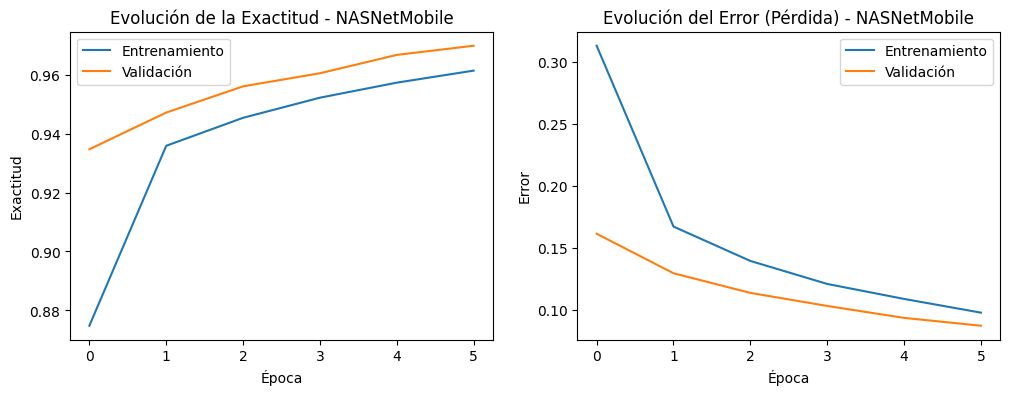


Generando evaluación detallada...

71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step


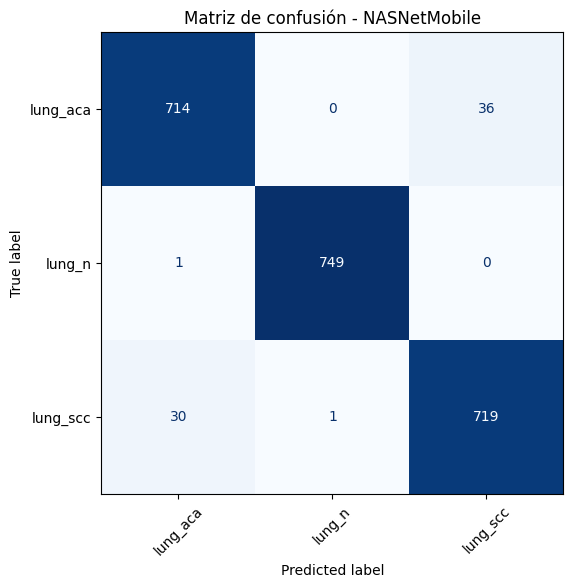


Exactitud en validación (NASNetMobile): 96.98%

Reporte de clasificación - NASNetMobile:
              precision    recall  f1-score   support

    lung_aca       0.96      0.95      0.96       750
      lung_n       1.00      1.00      1.00       750
    lung_scc       0.95      0.96      0.96       750

    accuracy                           0.97      2250
   macro avg       0.97      0.97      0.97      2250
weighted avg       0.97      0.97      0.97      2250



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- PARTE A: GRÁFICAS DE APRENDIZAJE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica 1: Exactitud (Accuracy)
ax1.plot(history_nas.history['accuracy'], label='Entrenamiento')
ax1.plot(history_nas.history['val_accuracy'], label='Validación')
ax1.set_title('Evolución de la Exactitud - NASNetMobile')
ax1.set_ylabel('Exactitud')
ax1.set_xlabel('Época')
ax1.legend()

# Gráfica 2: Pérdida (Error)
ax2.plot(history_nas.history['loss'], label='Entrenamiento')
ax2.plot(history_nas.history['val_loss'], label='Validación')
ax2.set_title('Evolución del Error (Pérdida) - NASNetMobile')
ax2.set_ylabel('Error')
ax2.set_xlabel('Época')
ax2.legend()
plt.show()

# --- PARTE B: MATRIZ DE CONFUSIÓN Y REPORTE ---
print("\nGenerando evaluación detallada...\n")

# 1. Reiniciamos el generador para asegurar que leemos desde el principio
val_generator.reset()

# 2. Calculamos los pasos exactos de validación para no omitir ninguna imagen
val_steps = val_generator.samples // val_generator.batch_size + int(val_generator.samples % val_generator.batch_size != 0)

# 3. Hacemos las predicciones con el modelo NASNetMobile
y_prob_nas = model_nasnet.predict(val_generator, steps=val_steps)

# 4. Obtenemos la clase con mayor probabilidad
y_pred_nas = np.argmax(y_prob_nas, axis=1)

# 5. Obtenemos las etiquetas reales
y_true = val_generator.classes

# 6. Nombres de las etiquetas (Sano, Adenocarcinoma, etc.)
labels = list(val_generator.class_indices.keys())

# 7. Calculamos la matriz de confusión
cm_nas = confusion_matrix(y_true, y_pred_nas)

# 8. Graficamos usando ConfusionMatrixDisplay (tu método)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nas, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Matriz de confusión - NASNetMobile")
# Rotamos las etiquetas 45 grados para que no se empalmen los nombres largos
plt.xticks(rotation=45)
plt.show()

# 9. Calculamos la exactitud manual usando la traza de la matriz
acc_val_nas = np.trace(cm_nas) / np.sum(cm_nas)
print(f"\nExactitud en validación (NASNetMobile): {acc_val_nas*100:.2f}%")

# 10. Imprimimos el reporte de clasificación detallado
print("\nReporte de clasificación - NASNetMobile:")
print(classification_report(y_true, y_pred_nas, target_names=labels))

# **Este modelo si cumple con las expectativas de la tarea al obtener 96.98% ✅**

# **Probar de nuevo el modelo DenseNet121 pero ahora con ZIP FILE en google drive debido al tiempo de ejecución y aumentando epocas ⏲**

22. Extracción Rápida (Método ZIP)

In [18]:
from google.colab import drive
import zipfile
import os

# 1. Conectamos nuestro Google Drive a la computadora temporal de Colab
drive.mount('/content/drive')

# 2. La ruta donde se guardo el archivo ZIP
ruta_zip = '/content/drive/MyDrive/UACJ/Redes Neuronales Profundas/Colab_Datasets/LC25000.zip'

# 3. La carpeta "local" (ultrarrápida) donde se van a vaciar las imágenes
directorio_local = '/content/dataset_local'

if not os.path.exists(directorio_local):
    os.makedirs(directorio_local)

# 4. Abrimos el ZIP y sacamos las imágenes directo a la memoria rápida
print("Extrayendo imágenes a la memoria rápida de Colab...")
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(directorio_local)
print("¡Extracción completada exitosamente!")

# 5. Buscamos la carpeta final que contiene los 3 tipos de pulmones
ruta_datos = os.path.join(directorio_local, 'lung_colon_image_set', 'lung_image_sets')
if not os.path.exists(ruta_datos):
    ruta_datos = directorio_local

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extrayendo imágenes a la memoria rápida de Colab...
¡Extracción completada exitosamente!


23. PREPARACIÓN Y LECTURA DE IMÁGENES (CONJUNTO 85% y 15%)

Para DenseNet ya no usamos rescale=1./255 porque este modelo necesita los colores originales para procesarlos él mismo con su propia fórmula. Solo separamos el 15% para exámenes.

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Creamos el generador.
# Nota importante: No usamos "rescale" aquí porque DenseNet prefiere procesar
# los colores (0 a 255) internamente con su propia función.
datagen = ImageDataGenerator(
    validation_split=0.15  # Guardamos el 15% estricto para validar
)

print("--- Cargando conjunto de ENTRENAMIENTO (85%) ---")
train_generator = datagen.flow_from_directory(
    ruta_datos,
    target_size=(224, 224),  # DenseNet exige imágenes de 224x224
    batch_size=32,           # Pasamos las imágenes de 32 en 32
    class_mode='categorical',# 3 clases: Sano, Adenocarcinoma, Carcinoma
    subset='training',       # Esto es para que la red estudie
    shuffle=True             # Revolvemos las imágenes (esencial para estudiar)
)

print("\n--- Cargando conjunto de VALIDACIÓN (15%) ---")
val_generator = datagen.flow_from_directory(
    ruta_datos,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',     # Esto es para el examen final
    shuffle=False            # En el examen NO se revuelven (para la matriz de confusión)
)

--- Cargando conjunto de ENTRENAMIENTO (85%) ---
Found 12750 images belonging to 3 classes.

--- Cargando conjunto de VALIDACIÓN (15%) ---
Found 2250 images belonging to 3 classes.


24. CONSTRUCCIÓN DEL MODELO DENSENET121

In [20]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input # LA SOLUCIÓN AL PROBLEMA DE COLORES
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Creamos la "puerta de entrada" para nuestras imágenes de 224x224
entrada = Input(shape=(224, 224, 3))

# 2. PREPROCESAMIENTO: Transforma los colores crudos a la fórmula exacta que DenseNet entiende.
# Si no ponemos esto, la red se queda ciega y da 33% de exactitud.
x = preprocess_input(entrada)

# 3. Importamos la base de DenseNet121 (ya sabe identificar texturas y formas)
modelo_base_dense = DenseNet121(weights='imagenet', include_top=False)

# 4. CONGELAMOS la base (Instrucción de la tarea)
modelo_base_dense.trainable = False

# 5. Pasamos nuestras imágenes a través del conocimiento de DenseNet
x = modelo_base_dense(x)

# 6. AÑADIMOS EL "CEREBRO" NUEVO PARA PULMONES
x = GlobalAveragePooling2D()(x)       # Aplanamos la información visual
x = Dense(256, activation='relu')(x)  # Capa de neuronas para aprender patrones
x = Dropout(0.5)(x)                   # Apagamos 50% de neuronas para evitar que memorice

# 7. CAPA DE SALIDA (Para clasificar las 3 enfermedades)
predicciones_dense = Dense(3, activation='softmax')(x)

# 8. Unimos todo (Entrada + DenseNet + Capas Nuevas)
model_dense = Model(inputs=entrada, outputs=predicciones_dense)

# 9. COMPILAMOS (Configuramos el entrenamiento)
model_dense.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo DenseNet121 construido correctamente")

Modelo DenseNet121 construido correctamente


25. PRIMERA FASE DE ENTRENAMIENTO

In [21]:
print("Iniciando Fase 1: Entrenando solo las capas nuevas...")

# Entrenamos por 5 épocas iniciales.
# La base sigue congelada, solo estamos enseñándole a las capas nuevas a leer a DenseNet.
history_dense_fase1 = model_dense.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    verbose=1
)

Iniciando Fase 1: Entrenando solo las capas nuevas...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 136s 270ms/step - accuracy: 0.7741 - loss: 0.5215 - val_accuracy: 0.9462 - val_loss: 0.1371
Epoch 2/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 67s 168ms/step - accuracy: 0.9459 - loss: 0.1536 - val_accuracy: 0.9569 - val_loss: 0.1087
Epoch 3/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 68s 169ms/step - accuracy: 0.9540 - loss: 0.1155 - val_accuracy: 0.9604 - val_loss: 0.0956
Epoch 4/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 81s 168ms/step - accuracy: 0.9571 - loss: 0.1107 - val_accuracy: 0.9600 - val_loss: 0.0888
Epoch 5/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 86s 178ms/step - accuracy: 0.9658 - loss: 0.0906 - val_accuracy: 0.9680 - val_loss: 0.0820


26. EVALUACIÓN FASE 1 (ANTES DEL FINE-TUNING)

--- RESULTADOS DE LA FASE 1 (Solo capas nuevas) ---


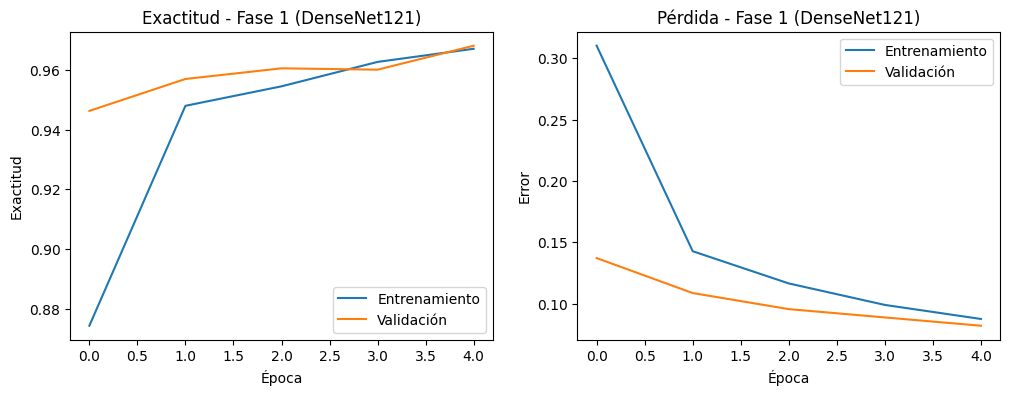

71/71 ━━━━━━━━━━━━━━━━━━━━ 39s 355ms/step


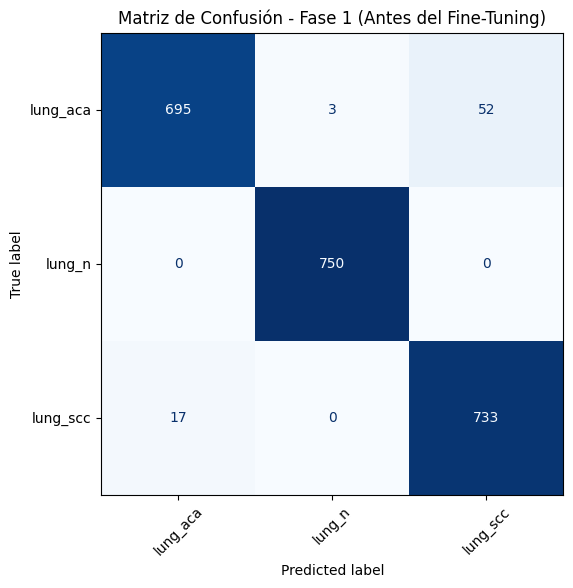


Exactitud en validación (Fase 1): 96.80%

Reporte de Clasificación (Fase 1):
              precision    recall  f1-score   support

    lung_aca       0.98      0.93      0.95       750
      lung_n       1.00      1.00      1.00       750
    lung_scc       0.93      0.98      0.96       750

    accuracy                           0.97      2250
   macro avg       0.97      0.97      0.97      2250
weighted avg       0.97      0.97      0.97      2250



In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("--- RESULTADOS DE LA FASE 1 (Solo capas nuevas) ---")

# --- 1. GRÁFICAS DE APRENDIZAJE (FASE 1) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de Exactitud
ax1.plot(history_dense_fase1.history['accuracy'], label='Entrenamiento')
ax1.plot(history_dense_fase1.history['val_accuracy'], label='Validación')
ax1.set_title('Exactitud - Fase 1 (DenseNet121)')
ax1.set_ylabel('Exactitud')
ax1.set_xlabel('Época')
ax1.legend()

# Gráfica de Pérdida
ax2.plot(history_dense_fase1.history['loss'], label='Entrenamiento')
ax2.plot(history_dense_fase1.history['val_loss'], label='Validación')
ax2.set_title('Pérdida - Fase 1 (DenseNet121)')
ax2.set_ylabel('Error')
ax2.set_xlabel('Época')
ax2.legend()
plt.show()

# --- 2. MATRIZ DE CONFUSIÓN Y REPORTE (FASE 1) ---
# Reiniciamos las imágenes de examen para leerlas en orden
val_generator.reset()
val_steps = val_generator.samples // val_generator.batch_size + int(val_generator.samples % val_generator.batch_size != 0)

# La IA hace el primer examen
y_prob_fase1 = model_dense.predict(val_generator, steps=val_steps)
y_pred_fase1 = np.argmax(y_prob_fase1, axis=1)
y_true = val_generator.classes
labels = list(val_generator.class_indices.keys())

# Dibujamos la matriz de la Fase 1
cm_fase1 = confusion_matrix(y_true, y_pred_fase1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_fase1, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp1.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Matriz de Confusión - Fase 1 (Antes del Fine-Tuning)")
plt.xticks(rotation=45)
plt.show()

# Calculamos e imprimimos el reporte de la Fase 1
acc_val_fase1 = np.trace(cm_fase1) / np.sum(cm_fase1)
print(f"\nExactitud en validación (Fase 1): {acc_val_fase1*100:.2f}%\n")
print("Reporte de Clasificación (Fase 1):")
print(classification_report(y_true, y_pred_fase1, target_names=labels))

**Esta vez sí obtuvimos un valor por arriba de 96%; por fines didácticos se hace el segundo método del fine-tuning.**

27. SEGUNDA FASE (FINE-TUNING)

In [25]:
print("Iniciando Fase 2: Ajuste Fino (Fine-Tuning)...")

# 1. Descongelamos TODA la base de DenseNet
modelo_base_dense.trainable = True

# 2. Volvemos a congelar casi todas las capas EXCEPTO las últimas 20.
for layer in modelo_base_dense.layers[:-20]:
    layer.trainable = False

# Comprobamos cuántas capas se van a ajustar ahora
capas_entrenables = np.sum([layer.trainable for layer in modelo_base_dense.layers])
print(f"Capas convolucionales profundas listas para ajuste fino: {capas_entrenables}")

# 3. VOLVEMOS A COMPILAR EL MODELO con una velocidad de aprendizaje minúscula (1e-5)
from tensorflow.keras.optimizers import Adam
model_dense.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Entrenamos por unas cuantas épocas extra para pulir los detalles
history_dense_fase2 = model_dense.fit(
    train_generator,
    epochs=4,
    validation_data=val_generator,
    verbose=1
)

Iniciando Fase 2: Ajuste Fino (Fine-Tuning)...
Capas convolucionales profundas listas para ajuste fino: 20
Epoch 1/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 143s 275ms/step - accuracy: 0.9112 - loss: 0.2563 - val_accuracy: 0.9667 - val_loss: 0.0810
Epoch 2/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 78s 196ms/step - accuracy: 0.9549 - loss: 0.1096 - val_accuracy: 0.9689 - val_loss: 0.0731
Epoch 3/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 72s 180ms/step - accuracy: 0.9593 - loss: 0.1028 - val_accuracy: 0.9733 - val_loss: 0.0663
Epoch 4/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 68s 169ms/step - accuracy: 0.9647 - loss: 0.0868 - val_accuracy: 0.9764 - val_loss: 0.0607


 27. EVALUACIÓN FASE 2 (DESPUÉS DEL FINE-TUNING)

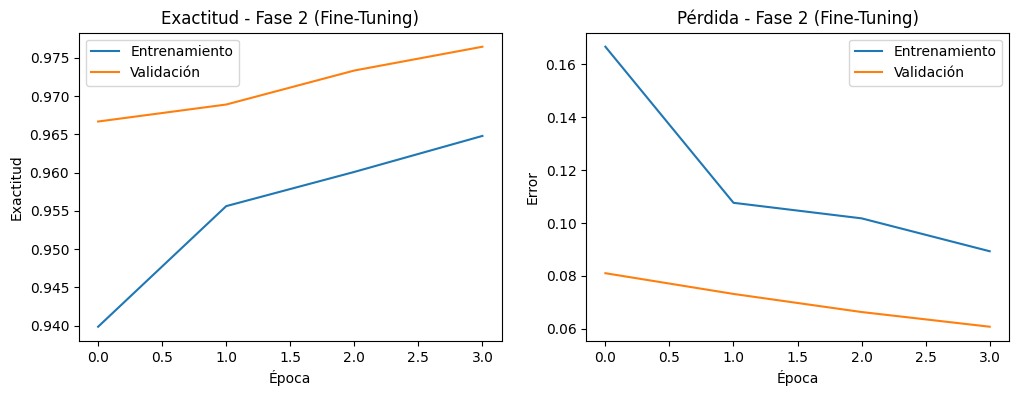

71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 346ms/step


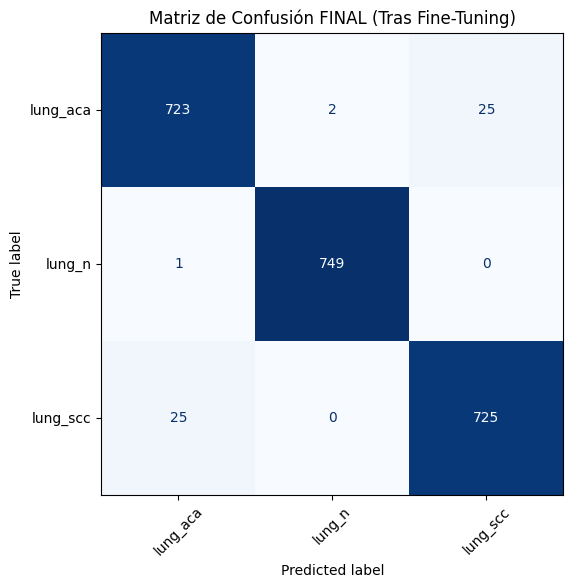


Exactitud en validación FINAL: 97.64%

Reporte de Clasificación FINAL:
              precision    recall  f1-score   support

    lung_aca       0.97      0.96      0.96       750
      lung_n       1.00      1.00      1.00       750
    lung_scc       0.97      0.97      0.97       750

    accuracy                           0.98      2250
   macro avg       0.98      0.98      0.98      2250
weighted avg       0.98      0.98      0.98      2250



In [26]:
# --- 1. GRÁFICAS DE APRENDIZAJE (FASE 2) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_dense_fase2.history['accuracy'], label='Entrenamiento')
ax1.plot(history_dense_fase2.history['val_accuracy'], label='Validación')
ax1.set_title('Exactitud - Fase 2 (Fine-Tuning)')
ax1.set_ylabel('Exactitud')
ax1.set_xlabel('Época')
ax1.legend()

ax2.plot(history_dense_fase2.history['loss'], label='Entrenamiento')
ax2.plot(history_dense_fase2.history['val_loss'], label='Validación')
ax2.set_title('Pérdida - Fase 2 (Fine-Tuning)')
ax2.set_ylabel('Error')
ax2.set_xlabel('Época')
ax2.legend()
plt.show()

# --- 2. MATRIZ DE CONFUSIÓN Y REPORTE FINAL ---
# Reiniciamos las imágenes para el último examen
val_generator.reset()

# La IA hace el segundo examen con el modelo ajustado
y_prob_fase2 = model_dense.predict(val_generator, steps=val_steps)
y_pred_fase2 = np.argmax(y_prob_fase2, axis=1)

# Dibujamos la matriz de la Fase 2
cm_fase2 = confusion_matrix(y_true, y_pred_fase2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_fase2, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp2.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Matriz de Confusión FINAL (Tras Fine-Tuning)")
plt.xticks(rotation=45)
plt.show()

# Calculamos e imprimimos el reporte final
acc_val_fase2 = np.trace(cm_fase2) / np.sum(cm_fase2)
print(f"\nExactitud en validación FINAL: {acc_val_fase2*100:.2f}%\n")
print("Reporte de Clasificación FINAL:")
print(classification_report(y_true, y_pred_fase2, target_names=labels))

# **Este modelo si cumple con las expectativas de la tarea al obtener 97.64% ✅**

Como conclusión, podemos notar que el modelo sí aumentó su precisión de 96.80% a 97.64% utilizando el método fine-tuning.


Se utilizo la siguiente dirreción https://keras.io/api/applications/ para ver los modelos a seleccionar, todos superaron el promedio del Top-5 Accuracy.